# Kernel Model Multi-Config Experiments
Run multiple configurations, then generate heatmaps for each trained model.


In [2]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from kernel_model.config import (
    PatchExtractionConfig,
    KernelBankConfig,
    SelectionConfig,
    TrainingConfig,
    SubsetSearchConfig,
    PipelineConfig,
)
from kernel_model.pipeline import run_pipeline
from kernel_model.responses import compute_responses


## Config builder
Edit the defaults here and in the configs list below.


In [5]:
def make_cfg(
    *,
    name,
    model_type="mlp",
    K=5,
    topM=300,
    standardize_features=True,
    standardize_responses=False,
    train_subset_frac=None,
    train_subset_size=None,
    plot_top_kernels=False,
):
    cfg = PipelineConfig(
        data=PatchExtractionConfig(
            healthy_dir=Path('data/TIFF Images/Normal'),
            malignant_dir=Path('data/TIFF Images/Malignant'),
            annotation_dir=Path('data/TIFF Images/malignantAnnotation'),
            output_dir=Path('data/patches'),
            patch_size=128,
            n_inside_per_image=40,
            n_outside_per_image=10,
            red_threshold=150,
            max_tries=250,
            min_nonzero_frac=0.35,
            run_extraction=False,
        ),
        bank=KernelBankConfig(),
        selection=SelectionConfig(
            method='mmr',
            topM=topM,
            K=K,
            plot_top_kernels=plot_top_kernels,
            standardize_responses=standardize_responses,
        ),
        training=TrainingConfig(
            model_type=model_type,
            standardize_features=standardize_features,
            train_subset_frac=train_subset_frac,
            train_subset_size=train_subset_size,
        ),
        subset=SubsetSearchConfig(
            pair_corr_threshold=0.0,
        ),
        data_root=Path('data/patches'),
        out_dir=Path('results'),
        max_per_class=3000,
        resize_patch_size=128,
    )
    cfg._name = name
    return cfg


## Define experiments
Add or edit entries in `configs` to run multiple experiments back-to-back.


In [6]:
configs = [
    make_cfg(name='logistic_k3', model_type='logistic', K=3, standardize_features=False, plot_top_kernels=True),
    make_cfg(name='logistic_k5', model_type='logistic', K=5, standardize_features=False, plot_top_kernels=True),
    make_cfg(name='logistic_k200', model_type='logistic', K=200, standardize_features=False, plot_top_kernels=False),
    make_cfg(name='logistic_k300', model_type='logistic', K=300, standardize_features=False, plot_top_kernels=False),
]


## Run experiments
This will create a new `results/exp_###` folder for each run.


In [7]:
results = []
for cfg in configs:
    print(f'Running {cfg._name}...')
    res = run_pipeline(cfg)
    results.append({'name': cfg._name, 'cfg': cfg, 'result': res})
results


2026-01-26 15:04:37,346 [INFO] Starting pipeline. Output: results/exp_022 Device: cuda Selection: mmr


Running logistic_k3...


2026-01-26 15:04:39,402 [INFO] Loaded train split: Xin=2800 Xout=3000 resize=128 (patients in=70 out=293)
2026-01-26 15:04:39,979 [INFO] Loaded val split: Xin=1040 Xout=750 resize=128 (patients in=26 out=73)
2026-01-26 15:04:40,582 [INFO] Loaded test split: Xin=1040 Xout=830 resize=128 (patients in=26 out=73)
2026-01-26 15:04:40,694 [INFO] Built kernel bank: 1800 kernels
Kernels: 100%|██████████| 1800/1800 [10:19<00:00,  2.91it/s]
2026-01-26 15:15:03,918 [INFO] Patient-level grouping enabled (303 unique ids)
2026-01-26 15:15:07,850 [INFO] MMR selected kernels (bank idx): [297, 961, 915]
2026-01-26 15:15:14,801 [INFO] Classifier results: AUC=0.9275 ACC=0.7339
Kernels: 100%|██████████| 1800/1800 [11:49<00:00,  2.54it/s]
2026-01-26 15:27:05,281 [INFO] Eval val: AUC=0.9085 ACC=0.8011
Kernels: 100%|██████████| 1800/1800 [03:12<00:00,  9.34it/s]
2026-01-26 15:30:18,083 [INFO] Eval test: AUC=0.9239 ACC=0.7914
2026-01-26 15:30:18,084 [INFO] No kernel pair met correlation threshold 0.000
2026-0

Running logistic_k5...


2026-01-26 15:30:20,288 [INFO] Loaded train split: Xin=2800 Xout=3000 resize=128 (patients in=70 out=293)
2026-01-26 15:30:20,907 [INFO] Loaded val split: Xin=1040 Xout=750 resize=128 (patients in=26 out=73)
2026-01-26 15:30:21,541 [INFO] Loaded test split: Xin=1040 Xout=830 resize=128 (patients in=26 out=73)
2026-01-26 15:30:21,664 [INFO] Built kernel bank: 1800 kernels
Kernels: 100%|██████████| 1800/1800 [22:33<00:00,  1.33it/s]
2026-01-26 15:52:58,515 [INFO] Patient-level grouping enabled (303 unique ids)
2026-01-26 15:53:01,775 [INFO] MMR selected kernels (bank idx): [237, 32, 1181, 340, 289]
2026-01-26 15:53:07,098 [INFO] Classifier results: AUC=0.9273 ACC=0.6927
Kernels: 100%|██████████| 1800/1800 [03:03<00:00,  9.80it/s]
2026-01-26 15:56:11,204 [INFO] Eval val: AUC=0.9071 ACC=0.7765
Kernels: 100%|██████████| 1800/1800 [03:16<00:00,  9.15it/s]
2026-01-26 15:59:27,927 [INFO] Eval test: AUC=0.9234 ACC=0.7594
2026-01-26 15:59:27,928 [INFO] No kernel pair met correlation threshold 0.

Running logistic_k200...


2026-01-26 15:59:30,206 [INFO] Loaded train split: Xin=2800 Xout=3000 resize=128 (patients in=70 out=293)
2026-01-26 15:59:30,827 [INFO] Loaded val split: Xin=1040 Xout=750 resize=128 (patients in=26 out=73)
2026-01-26 15:59:31,493 [INFO] Loaded test split: Xin=1040 Xout=830 resize=128 (patients in=26 out=73)
2026-01-26 15:59:31,630 [INFO] Built kernel bank: 1800 kernels
Kernels: 100%|██████████| 1800/1800 [32:47<00:00,  1.09s/it]
2026-01-26 16:32:22,362 [INFO] Patient-level grouping enabled (303 unique ids)
2026-01-26 16:33:49,840 [INFO] MMR selected kernels (bank idx): [281, 352, 1185, 327, 210, 387, 312, 310, 350, 216, 272, 188, 340, 118, 93, 214, 32, 59, 168, 273, 97, 57, 260, 363, 215, 62, 375, 349, 129, 2, 385, 393, 127, 248, 130, 213, 302, 258, 128, 343, 120, 369, 303, 265, 194, 394, 276, 267, 268, 270, 238, 23, 108, 379, 1, 358, 226, 60, 8, 180, 339, 316, 48, 336, 286, 105, 153, 396, 24, 308, 132, 77, 378, 177, 73, 294, 271, 159, 325, 266, 335, 372, 84, 279, 364, 383, 341, 107,

Running logistic_k300...


2026-01-26 16:40:10,333 [INFO] Loaded train split: Xin=2800 Xout=3000 resize=128 (patients in=70 out=293)
2026-01-26 16:40:10,949 [INFO] Loaded val split: Xin=1040 Xout=750 resize=128 (patients in=26 out=73)
2026-01-26 16:40:11,602 [INFO] Loaded test split: Xin=1040 Xout=830 resize=128 (patients in=26 out=73)
2026-01-26 16:40:11,730 [INFO] Built kernel bank: 1800 kernels
Kernels: 100%|██████████| 1800/1800 [37:08<00:00,  1.24s/it]
2026-01-26 17:17:25,159 [INFO] Patient-level grouping enabled (303 unique ids)
2026-01-26 17:19:38,900 [INFO] MMR selected kernels (bank idx): [272, 947, 283, 1137, 347, 288, 377, 205, 286, 203, 318, 207, 289, 344, 274, 269, 341, 255, 363, 23, 86, 10, 215, 312, 139, 313, 310, 227, 38, 47, 308, 356, 223, 328, 62, 285, 172, 198, 36, 97, 163, 69, 111, 200, 270, 110, 91, 357, 858, 20, 314, 19, 68, 253, 333, 138, 41, 394, 123, 54, 304, 190, 353, 43, 61, 30, 173, 252, 352, 277, 324, 322, 116, 284, 366, 159, 231, 53, 147, 9, 359, 355, 149, 390, 125, 136, 27, 292, 18

[{'name': 'logistic_k3',
  'cfg': PipelineConfig(data=PatchExtractionConfig(healthy_dir=PosixPath('data/TIFF Images/Normal'), malignant_dir=PosixPath('data/TIFF Images/Malignant'), annotation_dir=PosixPath('data/TIFF Images/malignantAnnotation'), output_dir=PosixPath('data/patches'), patch_size=128, n_inside_per_image=40, n_outside_per_image=10, red_threshold=150, max_tries=250, min_pos_coverage=0.8, max_neg_coverage=0.02, near_neg_fraction=0.2, near_neg_radius=None, far_neg_radius=None, use_bbox_for_positives=False, min_nonzero_frac=0.35, min_intensity_rel=0.0, split_patients=True, train_frac=0.7, val_frac=0.15, test_frac=0.15, split_seed=42, run_extraction=False), bank=KernelBankConfig(families=('gaussian', 'anisotropic_gaussian', 'dog', 'log', 'gabor', 'hog', 'glcm', 'lbp', 'mrf'), n_per_family=200, kernel_size=31), selection=SelectionConfig(method='mmr', response_fn='abs_max', topM=300, K=3, lambda_mm=0.75, plot_top_kernels=True, standardize_responses=False), training=TrainingConfi

## Heatmap utilities
Generate a patch-level heatmap for a given image using a trained model.


In [8]:
def render_heatmap(result, cfg, img_path, stride=None, save_path=None, show=True):
    model = result['clf']['model']
    if model is None:
        raise RuntimeError('No model found in result. Ensure run_pipeline completed.')
    model.eval()
    model_device = next(model.parameters()).device

    out_dir = Path(result['out_dir'])
    kernels = np.load(out_dir / 'kernels.npy').astype(np.float32)
    selected_idxs = result.get('selected_idxs')
    if selected_idxs is None:
        selected_idxs = np.load(out_dir / 'results.npz')['selected_idxs'].astype(int).tolist()

    selected_kernels = kernels[np.array(selected_idxs, dtype=int)]
    bank_selected = [{'kernel': k} for k in selected_kernels]

    patch_size = int(cfg.data.patch_size)
    model_patch_size = int(cfg.resize_patch_size) if cfg.resize_patch_size else patch_size
    if stride is None:
        stride = max(1, patch_size // 4)

    img = Image.open(img_path).convert('L')
    img_arr = np.array(img, dtype=np.float32) / 255.0
    H, W = img_arr.shape

    def _grid_starts(length, patch, step):
        if length < patch:
            return []
        starts = list(range(0, length - patch + 1, step))
        if starts and starts[-1] != length - patch:
            starts.append(length - patch)
        return starts

    ys = _grid_starts(H, patch_size, stride)
    xs = _grid_starts(W, patch_size, stride)
    if not ys or not xs:
        raise ValueError(f'Image is smaller than patch size: {img_arr.shape} vs {patch_size}')

    patches = []
    coords = []
    for y in ys:
        for x in xs:
            patch = img_arr[y : y + patch_size, x : x + patch_size]
            if model_patch_size != patch_size:
                patch = np.array(
                    Image.fromarray((patch * 255).astype(np.uint8)).resize(
                        (model_patch_size, model_patch_size), Image.BILINEAR
                    ),
                    dtype=np.float32,
                ) / 255.0
            patches.append(patch)
            coords.append((y, x))
    patches = np.stack(patches, axis=0).astype(np.float32)

    X_empty = np.zeros((0, patches.shape[1], patches.shape[2]), dtype=patches.dtype)
    responses = compute_responses(
        bank_selected,
        patches,
        X_empty,
        device=model_device,
        batch_size=cfg.training.batch_size,
        response_fn=cfg.selection.response_fn,
        standardize_patches=cfg.selection.standardize_responses,
    )
    X_feat = (
        np.stack([r['r_in'] for r in responses], axis=1)
        if responses
        else np.zeros((len(patches), 0), dtype=np.float32)
    )

    if result['clf'].get('standardize') and result['clf'].get('mean') is not None and result['clf'].get('std') is not None:
        mean = result['clf']['mean']
        std = result['clf']['std']
        X_feat = (X_feat - mean) / std

    with torch.no_grad():
        logits = model(torch.from_numpy(X_feat).float().to(model_device))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

    heatmap = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)
    for (y, x), p in zip(coords, probs):
        heatmap[y : y + patch_size, x : x + patch_size] += p
        count[y : y + patch_size, x : x + patch_size] += 1.0
    heatmap = heatmap / np.maximum(count, 1.0)

    plt.figure(figsize=(7, 7))
    plt.imshow(img_arr, cmap='gray')
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.colorbar(label='Cancer probability')
    plt.title(f'Heatmap | {Path(img_path).name} | max={probs.max():.3f} mean={probs.mean():.3f}')
    plt.axis('off')

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close()


## Generate heatmaps for all experiments
Update the image list, then run this cell.


In [14]:
img_paths = [
    Path('data/TIFF Images/Normal/IMG330.tif'),
    Path('data/TIFF Images/Malignant/IMG044.tif'),
    Path('data/TIFF Images/Normal/IMG332.tif'),
    Path('data/TIFF Images/Malignant/IMG111.tif'),
    Path('data/TIFF Images/Normal/IMG366.tif'),
    Path('data/TIFF Images/Malignant/IMG222.tif')
]

for item in results:
    name = item['name']
    res = item['result']
    cfg = item['cfg']
    save_dir = Path(res['out_dir']) / 'heatmaps'
    for img_path in img_paths:
        save_path = save_dir / f'{img_path.stem}_{name}_heatmap.png'
        render_heatmap(res, cfg, img_path, save_path=save_path, show=False)
        print(f'Saved: {save_path}')


Kernels: 100%|██████████| 3/3 [00:26<00:00,  8.87s/it]


Saved: results/exp_022/heatmaps/IMG330_logistic_k3_heatmap.png


Kernels: 100%|██████████| 3/3 [00:15<00:00,  5.24s/it]


Saved: results/exp_022/heatmaps/IMG044_logistic_k3_heatmap.png


Kernels: 100%|██████████| 3/3 [00:25<00:00,  8.62s/it]


...

Saved: results/exp_025/heatmaps/IMG111_logistic_k300_heatmap.png


Kernels: 100%|██████████| 300/300 [37:43<00:00,  7.55s/it]


Saved: results/exp_025/heatmaps/IMG366_logistic_k300_heatmap.png


Kernels: 100%|██████████| 300/300 [33:10<00:00,  6.64s/it]


Saved: results/exp_025/heatmaps/IMG222_logistic_k300_heatmap.png


## Experiment summary plot
This cell summarizes multi-config runs and saves a compact AUC/ACC comparison plot.


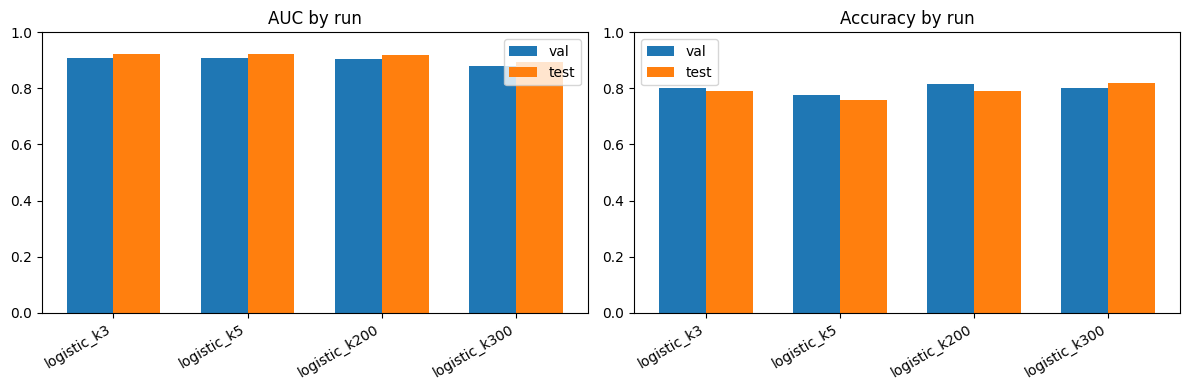

Saved summary plot: results/multi_config_summary.png


In [15]:
import json
from pathlib import Path

def _collect_runs(results_list=None, exp_dirs=None):
    runs = []
    if results_list:
        for item in results_list:
            cfg = item['cfg']
            res = item['result']
            label = item.get('name', 'run')
            runs.append({
                'label': label,
                'K': int(cfg.selection.K),
                'model_type': cfg.training.model_type,
                'val_auc': float(res['eval_results'].get('val', {}).get('auc', 0.0)),
                'val_acc': float(res['eval_results'].get('val', {}).get('acc', 0.0)),
                'test_auc': float(res['eval_results'].get('test', {}).get('auc', 0.0)),
                'test_acc': float(res['eval_results'].get('test', {}).get('acc', 0.0)),
            })
        return runs

    base = Path('results')
    if exp_dirs is None:
        exp_dirs = sorted(base.glob('exp_*'))
    for d in exp_dirs:
        cfg_path = d / 'config.json'
        res_path = d / 'results.json'
        if not (cfg_path.exists() and res_path.exists()):
            continue
        try:
            cfg = json.loads(cfg_path.read_text())
            res = json.loads(res_path.read_text())
        except Exception:
            continue
        sel = cfg.get('selection', {})
        train = cfg.get('training', {})
        label = f"{d.name}_K{sel.get('K', 'NA')}"
        runs.append({
            'label': label,
            'K': int(sel.get('K', 0) or 0),
            'model_type': train.get('model_type', 'unknown'),
            'val_auc': float(res.get('eval_results', {}).get('val', {}).get('auc', 0.0)),
            'val_acc': float(res.get('eval_results', {}).get('val', {}).get('acc', 0.0)),
            'test_auc': float(res.get('eval_results', {}).get('test', {}).get('auc', 0.0)),
            'test_acc': float(res.get('eval_results', {}).get('test', {}).get('acc', 0.0)),
        })
    return runs

# If you already ran the configs in this notebook, this will use them.
# Otherwise it falls back to scanning results/exp_* for config.json + results.json.
runs = _collect_runs(results if 'results' in globals() else None)
if not runs:
    raise RuntimeError('No runs found. Run the experiments or ensure results/exp_* contains config.json + results.json.')

# Sort by K for readability
runs = sorted(runs, key=lambda r: r['K'])
labels = [f"{r['label']}" for r in runs]
x = np.arange(len(runs))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(x - width/2, [r['val_auc'] for r in runs], width, label='val')
axes[0].bar(x + width/2, [r['test_auc'] for r in runs], width, label='test')
axes[0].set_title('AUC by run')
axes[0].set_ylim(0.0, 1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].legend()

axes[1].bar(x - width/2, [r['val_acc'] for r in runs], width, label='val')
axes[1].bar(x + width/2, [r['test_acc'] for r in runs], width, label='test')
axes[1].set_title('Accuracy by run')
axes[1].set_ylim(0.0, 1.0)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].legend()

plt.tight_layout()
summary_plot = Path('results') / 'multi_config_summary.png'
plt.savefig(summary_plot, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved summary plot: {summary_plot}')
